# 🏢 Precificação de Imóveis em São Paulo - Módulo Locação

Este notebook faz parte do ecossistema de Inteligência Artificial para o mercado imobiliário de São Paulo. Após a consolidação dos modelos de **Venda**, este módulo foca na estruturação, limpeza e treinamento de modelos preditivos voltados para o mercado de **Locação (Aluguel)**.

## 🎯 Objetivo
Desenvolver um pipeline de Machine Learning capaz de prever o valor do aluguel mensal de um imóvel com base em suas características físicas (área útil) e localização (bairro).

## 🛠️ Etapa 1: Carregamento e Diagnóstico Inicial da Base
Nesta etapa, isolamos os dados de locação e avaliamos a distribuição estatística da nossa variável alvo (`preco_aluguel`) para identificar a presença de ruídos ou outliers.

In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [39]:
df_bruto = pd.read_csv('../data/raw/housing_sp_city.csv', encoding='latin1')

In [40]:
# Filtrar estritamente as linhas de Locação
df_locacao = df_bruto[df_bruto['tipo_anuncio'] == 'LocaÃ§Ã£o'].copy()

In [41]:
#Verificar o tamanho da nova base de aluguel
print(f"Total de imóveis para LOCAÇÃO encontrados: {df_locacao.shape[0]}")
print("-" * 50)

Total de imóveis para LOCAÇÃO encontrados: 28632
--------------------------------------------------


In [42]:
# Vamos listar o nome de todas as colunas do arquivo para achar o nome correto do preço
print("Colunas disponíveis na base:")
print(list(df_bruto.columns))

Colunas disponíveis na base:
['logradouro', 'numero', 'bairro', 'cep', 'cidade', 'tipo_imovel', 'area_util', 'banheiros', 'suites', 'quartos', 'vagas_garagem', 'anuncio_criado', 'tipo_anuncio', 'preco_venda', 'taxa_condominio', 'periodicidade', 'preco_aluguel', 'iptu_ano']


In [43]:
print(df_locacao['preco_aluguel'].describe())

count      28619.00
mean       11058.42
std        77137.33
min           70.00
25%         2310.00
50%         4130.00
75%         9170.00
max     11900000.00
Name: preco_aluguel, dtype: float64


In [44]:
# Comando para desativar a notação científica e mostrar números normais
pd.options.display.float_format = '{:.2f}'.format

## 🧹 Etapa 2: Remoção de Outliers (Regra de Negócio)

A análise estatística inicial revelou distorções severas na variável `preco_aluguel`:
* Um valor mínimo de **R$ 70,00**, que indica ruído na base (anúncios diários, vagas de garagem ou erros de preenchimento).
* Um valor máximo de **R$ 11.900.000,00**, que claramente se trata de um outlier (possivelmente o preço de venda inserido incorretamente na coluna de locação).

Para blindar o modelo, aplicaremos um filtro baseado em limites realistas para o mercado imobiliário residencial de São Paulo:
* **Piso (Mínimo):** R$ 500,00/mês
* **Teto (Máximo):** R$ 35.000,00/mês

In [45]:
# 1. Aplicar os limites definidos na regra de negócio
df_locacao_limpo = df_locacao[(df_locacao['preco_aluguel'] >= 500) & (df_locacao['preco_aluguel'] <= 35000)].copy()

In [46]:
# 2. Exibir o balanço de linhas removidas
print(f"Imóveis na base original: {df_locacao.shape[0]}")
print(f"Imóveis após a limpeza:   {df_locacao_limpo.shape[0]}")
print(f"Total de outliers descartados: {df_locacao.shape[0] - df_locacao_limpo.shape[0]}")
print("-" * 50)

Imóveis na base original: 28632
Imóveis após a limpeza:   27199
Total de outliers descartados: 1433
--------------------------------------------------


In [47]:
# 3. Exibir o novo describe formatado
print(df_locacao_limpo['preco_aluguel'].describe())

count   27199.00
mean     6402.95
std      6350.13
min       507.00
25%      2289.00
50%      3849.00
75%      8211.00
max     35000.00
Name: preco_aluguel, dtype: float64


## ⚙️ Etapa 3: Feature Engineering - Target Encoding para os Bairros

Como os modelos baseados em árvores e distância operam apenas com dados numéricos, transformaremos a variável categórica `bairro` usando o **Target Encoding**. 

Cada bairro será mapeado para a **média dos valores de aluguel** praticados especificamente naquela região. Isso mantém a informação de valor imobiliário atrelada à localização sem inflar a dimensionalidade dos dados (como ocorreria com o One-Hot Encoding).

In [48]:
# 1. Calcular a média de aluguel por bairro
medias_bairro = df_locacao_limpo.groupby('bairro')['preco_aluguel'].mean().to_dict()

In [49]:
# 2. Criar a nova coluna mapeando os valores do dicionário
df_locacao_limpo['bairro_encoded'] = df_locacao_limpo['bairro'].map(medias_bairro)

In [50]:
# 3. Visualizar como ficou o mapeamento nas primeiras linhas
df_locacao_limpo[['bairro', 'bairro_encoded', 'area_util', 'preco_aluguel']].head()

,bairro,bairro_encoded,area_util,preco_aluguel
2,Bela Vista,6917.59,396.00,29829.00
5,Vila Uberabinha,6247.37,45.00,2450.00
18,Cidade MonÃ§Ãµes,9382.25,126.00,3849.00
20,Vila Pompeia,3642.36,274.00,7699.00
39,Jardim Guedala,13967.10,480.00,7000.00


## 🎯 Etapa 4: Divisão dos Dados (Features vs Target)

Com os dados limpos e transformados, isolaremos as variáveis explicativas (Features) da nossa variável dependente (Target). Em seguida, utilizaremos a estratégia clássica de divisão em **Treino e Teste** para garantir que a avaliação do modelo seja feita em dados inéditos.

In [51]:
X = df_locacao_limpo[['area_util', 'bairro_encoded']]
y = df_locacao_limpo['preco_aluguel']

In [52]:
# dividir treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
print(f'Dados de treino: {X_train.shape[0]} imóveis')
print(f'Dados de teste: {X_test.shape[0]} imóveis')
print(f'-' * 50)

Dados de treino: 21759 imóveis
Dados de teste: 5440 imóveis
--------------------------------------------------


In [54]:
# inicializar e treinar o modelo Random Forest
print('Treinando o modelo Random Forest para Locação!')
rf_locacao = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_locacao.fit(X_train, y_train)

Treinando o modelo Random Forest para Locação!


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
# 4. Fazer predições e avaliar as métricas
y_pred = rf_locacao.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [56]:
print(f"Métricas do Random Forest (Locação):")
print(f"MAE (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"R² Score (Poder de Explicação): {r2:.4f}")

Métricas do Random Forest (Locação):
MAE (Erro Médio Absoluto): R$ 1753.04
R² Score (Poder de Explicação): 0.7211


## ⚔️ Etapa 5: Modelo Competidor - KNN Regressor

Para fins de comparação e seleção do melhor modelo para a nossa API, treinaremos o algoritmo **KNN (K-Nearest Neighbors) Regressor**. O KNN tentará precificar o imóvel com base na média dos preços dos imóveis mais parecidos (vizinhos mais próximos) em termos de metragem e valor da região.

In [57]:
# 1. Garantir que não há nenhum valor ausente (NaN) nas colunas que vamos usar
df_locacao_limpo = df_locacao_limpo.dropna(subset=['area_util', 'bairro_encoded', 'preco_aluguel'])

In [58]:
# 2. Atualizar as variáveis X e y com a base 100% sem NaNs
X = df_locacao_limpo[['area_util', 'bairro_encoded']]
y = df_locacao_limpo['preco_aluguel']

In [59]:
# 3. Refazer a divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
# 4. inicializar e treinar o KNN de forma segura
print("Treinando o modelo KNN para Locação de forma limpa!")
knn_locacao = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_locacao.fit(X_train, y_train)

Treinando o modelo KNN para Locação de forma limpa!


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [61]:
# 5. Avaliar o KNN
y_pred_knn = knn_locacao.predict(X_test)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

In [62]:
print(f"Métricas do KNN (Locação):")
print(f"MAE (Erro Médio Absoluto): R$ {mae_knn:.2f}")
print(f"R² Score (Poder de Explicação): {r2_knn:.4f}")

Métricas do KNN (Locação):
MAE (Erro Médio Absoluto): R$ 1998.41
R² Score (Poder de Explicação): 0.6817


## 📉 Etapa 6: Modelo Competidor - Regressão Linear (Baseline)

A Regressão Linear será o nosso marco zero (baseline) estatístico. Ela tenta traçar uma linha reta matemática que cruza os dados minimizando a distância entre as previsões e os valores reais. Como baseia-se em equações lineares puras, utilizaremos as features padronizadas (`X_train_scaled`) para evitar distorções.

In [63]:
# 1. Garantir que limpamos os NaNs da base antes de qualquer treino
df_locacao_limpo = df_locacao_limpo.dropna(subset=['area_util', 'bairro_encoded', 'preco_aluguel'])


In [64]:
# 2. Separar as features (X) e o target (y)
X = df_locacao_limpo[['area_util', 'bairro_encoded']]
y = df_locacao_limpo['preco_aluguel']

In [65]:
# 3 Divisão treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# 4. Criar o Padronizador (Scaler) e aplicar nos dados para os modelos lineares/KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
# 5. Iniciar e treinar o modelo com dados escalados
lr_locacao = LinearRegression()
lr_locacao.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
# 6. Predição utilizando a base de teste escalada
y_pred_lr = lr_locacao.predict(X_test_scaled)

c:\Projetos\Python\MachineLearning\projeto-imoveis-sp\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [69]:
# 7. Calculo das méticas de validação
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [70]:
print("Métricas da Regressão Linear (Locação):")
print(f"MAE (Erro Médio Absoluto): R$ {mae_lr:.2f}")
print(f"R² Score (Poder de Explicação): {r2_lr:.4f}")

Métricas da Regressão Linear (Locação):
MAE (Erro Médio Absoluto): R$ 6506.09
R² Score (Poder de Explicação): -1.0343


## 📉 Etapa 7: Modelo Competidor - Ridge Regression (Regularização L2)

Para tentar corrigir a instabilidade da Regressão Linear tradicional, utilizaremos a **Ridge Regression**. Este algoritmo aplica uma penalidade matemática (Regularização L2) sobre os coeficientes do modelo, impedindo que eles assumam valores muito altos para tentar se ajustar aos extremos da base. Isso reduz a variância e tenta trazer um modelo linear mais estável para o ecossistema.

In [72]:
# 1. Iniciar e treinar o modelo Ridge 
ridge_locacao = Ridge(alpha=1.0)
ridge_locacao.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [73]:
# 2. Fazer as predições na bases de teste escalada
y_pred_ridge = ridge_locacao.predict(X_test_scaled)

In [74]:
# 3. Calcular as métricas de validação
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [75]:
print('Métricas da Ridge Regression (Locaçao): ')
print(f'MAE (Erro Médio Absoluto): R$ {mae_ridge:.2f}')
print(f'R² Score (Poder de Explicação): {r2_ridge:.4f}')

Métricas da Ridge Regression (Locaçao): 
MAE (Erro Médio Absoluto): R$ 3402.02
R² Score (Poder de Explicação): 0.2347


## 🌲 Etapa 8: Modelo Competidor - Árvore de Decisão Solo (Decision Tree)

Após o desempenho insatisfatório dos modelos lineares, migraremos para a família de algoritmos baseados em árvores de decisão. A Árvore de Decisão segmenta os dados através de quebras lógicas (regras de "Se-Então"), permitindo capturar padrões não-lineares complexos sem a necessidade de padronização das features (`X_train` original).

In [78]:
# 1. Inicializar e treinar a Árvore de Decisão 
dt_locacao = DecisionTreeRegressor(random_state=42)
dt_locacao.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [79]:
# 2. Fazer as predições na base de teste original
y_pred_dt = dt_locacao.predict(X_test)

In [80]:
# 3. Calcular as métricas de validação
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

In [81]:
print("Métricas da Árvore de Decisão (Locação):")
print(f"MAE (Erro Médio Absoluto): R$ {mae_dt:.2f}")
print(f"R² Score (Poder de Explicação): {r2_dt:.4f}")

Métricas da Árvore de Decisão (Locação):
MAE (Erro Médio Absoluto): R$ 2012.06
R² Score (Poder de Explicação): 0.6264


## 🚀 Etapa 9: Modelo Competidor - XGBoost Regressor (Gradient Boosting)

Para tentar superar o Random Forest, utilizaremos o **XGBoost (eXtreme Gradient Boosting)**. Diferente do Random Forest, que cria árvores independentes em paralelo, o XGBoost utiliza a estratégia de **Boosting**, onde as árvores são construídas de forma sequencial: cada nova árvore é treinada especificamente para corrigir os erros cometidos pelas árvores anteriores. É um dos algoritmos mais poderosos do estado da arte para dados estruturados.

In [85]:
# 1. Inicializar e Treinar o XGBoost
xgb_locacao = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_locacao.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [86]:
# 2. Fazer as predições na base de teste original
y_pred_xgb = xgb_locacao.predict(X_test)

In [87]:
# 3. Calcular as métricas de validação
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [88]:
print("Métricas do XGBoost Regressor (Locação):")
print(f"MAE (Erro Médio Absoluto): R$ {mae_xgb:.2f}")
print(f"R² Score (Poder de Explicação): {r2_xgb:.4f}")

Métricas do XGBoost Regressor (Locação):
MAE (Erro Médio Absoluto): R$ 1932.64
R² Score (Poder de Explicação): 0.7124


## 📊 Etapa 10: Análise Visual de Qualidade - Erro Percentual

Para validar a aplicabilidade do modelo no mundo real, calcularemos o **Erro Percentual Absoluto (APE)** para cada imóvel na base de teste. Em seguida, criaremos um gráfico de distribuição (histograma) para visualizar qual porcentagem das nossas previsões cai em faixas de erro aceitáveis pelo mercado (ex: até 10%, de 10% a 20%, etc.). Isso nos dá uma visão muito mais clara do risco do modelo do que apenas o erro absoluto em reais.

In [112]:
# 1. Gerar os arrays brutos
y_true_arr = np.array(y_test).flatten()
y_pred_arr = rf_locacao.predict(X_test).flatten()

In [113]:
# 2. Calcular o Erro Percentual Absoluto
erro_percentual = np.abs((y_true_arr - y_pred_arr) / y_true_arr) * 100

In [114]:
# 📊 PRINT ULTRA BRUTO: Vamos ver se o Python tá enxergando os números
print("--- TESTE DE DADOS ---")
print(f"Tamanho do array de erros: {len(erro_percentual)}")
print(f"Primeiros 10 erros calculados:\n{erro_percentual[:10]}")
print("----------------------")

--- TESTE DE DADOS ---
Tamanho do array de erros: 5345
Primeiros 10 erros calculados:
[ 1.83918173  1.45112673 39.98950223 24.66296785  4.38211814  4.28131213
 48.18003682 13.47305265 18.26047704 42.84001445]
----------------------


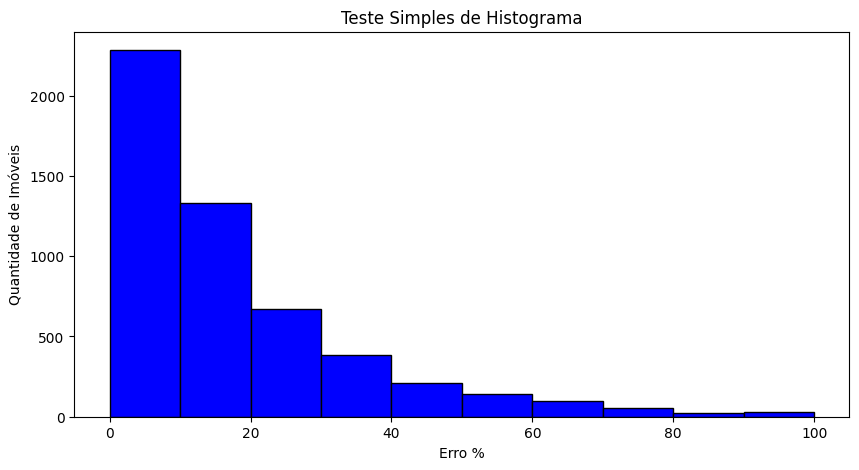

In [115]:
# 3. Configurar o gráfico usando o histplot (que calcula as barras sozinho)
plt.figure(figsize=(10, 5))
plt.hist(erro_percentual, bins=10, range=(0, 100), color='blue', edgecolor='black')
plt.title('Teste Simples de Histograma')
plt.xlabel('Erro %')
plt.ylabel('Quantidade de Imóveis')
plt.show()

In [116]:
import joblib

# 1. Salvar o modelo campeão absoluto de locação (Random Forest)
joblib.dump(rf_locacao, '../models/random_forest_locacao.pkl')

# 2. Salvar o scaler (fundamental para o KNN ou se formos usar dados escalados na API)
# Nota: certifique-se de que o nome da sua variável do scaler é exatamente 'scaler'
joblib.dump(scaler, '../models/scaler_locacao.pkl')

print("🏆 Modelo Random Forest e Scaler de Locação salvos com sucesso na pasta 'models'!")

🏆 Modelo Random Forest e Scaler de Locação salvos com sucesso na pasta 'models'!


In [117]:
import joblib

# Salvando com compressão (zlib nível 3 é excelente e rápido)
joblib.dump(rf_locacao, '../models/random_forest_locacao.pkl', compress=3)

print("🏆 Modelo re-salvo e compactado com sucesso!")

🏆 Modelo re-salvo e compactado com sucesso!
